# Traffic Model

## Release AIM

lfc/maveric issues #2. **Create Non-Trivial and Interesting Dummy Trac Model to Demonstrate the Benet of Energy Savings**

## objectives

0. questions
1. function: bdt_traffic_load()
2. traffic load model
3. traffic load optimizer (TLO) metric
4. x_app for energy savings


## obj 1: function: bdt_traffic_load()

Write a function that takes relevant input parameters to generate realistic trac data for the following eight scenarios:

Scenarios:

- Annual: 
    - 2020 vs 2024 Comparison
- Monthly (Seasonal):
    - O-Season/Vacation vs Normal Trac Patterns
    - Other Seasonal Examples
Weekly- :
    - Weekdays vs Weekends
    - Other Weekly Patterns
- Daily:
    - Day vs Night
    - Other Daily Variations

### city story

> come up with a city story and write digital model of that city.

**Hell's Kitchen** (oh yes daredevil fan) is a small, eco-friendly city designed with sustainability and efficiency in mind. It has a population of ~100,000 and is divided into distinct areas:

- Office & Business Hub
    - Two office areas (Downtown Core & Wall Street) house corporate offices, government buildings, and co-working spaces.
    - High public transit usage during peak hours.

- Residential Zones
    - Two neighborhoods: North Greenfield (high-rise apartments) and Westwood Villas (suburban homes).
    - Traffic varies by time (morning rush, evening return, weekend outings).

- Transportation Hubs
    - Central Station (train & bus) near Downtown.
    - Multiple bus routes and bike lanes.

- Entertainment District
    - Shopping malls, movie theaters, and a concert arena.
    - Peak traffic in the evening and weekends.

- Green Park
    - A large recreational park with cycling paths and lakes.
    - Visitors peak on weekends and afternoons.

- Industrial Zone
    - A logistics hub for warehouses and factories.
    - High transport traffic with trucks and service vehicles.

| **City Area**             | **Bing Tile (X, Y, Zoom)** | **Traffic Type**  | **Morning Footfall** | **Afternoon Footfall** | **Evening Footfall** | **Night Footfall** |
|--------------------------|------------------------|------------------|------------------|-------------------|----------------|---------------|
| Downtown Core           | (10, 12, 5)            | Office          | High (1.5×)     | Low (0.9×)       | Moderate (1.0×) | Low (0.5×)   |
| Wall Street            | (11, 12, 5)            | Office          | High (1.5×)     | Low (0.9×)       | Moderate (1.0×) | Low (0.5×)   |
| North Greenfield (Res)  | (8, 15, 5)             | Resident        | Moderate (0.8×) | Low (0.9×)       | High (1.5×)   | Moderate (0.8×) |
| Westwood Villas (Res)   | (7, 16, 5)             | Resident        | Moderate (0.8×) | Low (0.9×)       | High (1.5×)   | Moderate (0.8×) |
| Central Station        | (9, 14, 5)             | Transport       | High (1.5×)     | Moderate (1.0×)  | Moderate (1.0×) | Moderate (0.8×) |
| Entertainment District  | (11, 13, 5)            | Entertainment   | Low (0.8×)      | High (1.2×)      | High (1.5×)   | Low (0.5×)   |
| Green Park             | (12, 14, 5)            | Comprehensive   | Low (0.8×)      | High (1.2×)      | Moderate (1.0×) | Moderate (0.8×) |
| Industrial Zone        | (6, 18, 5)             | Transport       | High (1.5×)     | Moderate (1.0×)  | Moderate (1.0×) | Moderate (0.8×) |


### footfall

> **Footfall** refers to the number of people passing through a specific location over a given period. Can be measured in `people/hr`.

Examples of Footfall in Different City Areas:

- Office Areas (Downtown Core, Wall Street)
    - High footfall in the morning (8-10 AM) as people arrive for work.
    - High again in the evening (5-7 PM) when they leave.
    - Low at night.

- Residential Areas (North Greenfield, Westwood Villas)
    - Moderate footfall in the morning as people leave for work.
    - High in the evening when they return home.
    - Low at night and during work hours.

- Transport Hubs (Central Station)
    - Footfall remains steady throughout the day with minor peaks during rush hours.

- Entertainment District (Shopping Malls, Theaters, Arenas)
    - High in the evening and on weekends.
    - Low during work hours.

- Parks & Recreational Areas (Green Park)
    - High in the afternoon and on weekends.
    - Low during early mornings and late nights.

- Industrial Zones
    - Footfall mainly consists of workers and transport staff, peaking during work hours (8 AM - 6 PM).

In [1]:
import sys
from pathlib import Path
sys.path.append(f"{Path().absolute().parent}")

In [11]:
from enum import Enum
from random import randint

In [3]:
class TRAFFIC_TYPE(Enum):
    OFFICE = "office"
    RESIDENT = "resident"
    TRANSPORT = "transport"
    ENTERTAINMENT = "entertainment"
    COMPREHENSIVE = "comprehensive"

In [12]:
class CityGrid:
    def __init__(self):
        self.areas = {
            "Downtown Core": {"bing_tile": (10, 12, 5), "traffic_type": TRAFFIC_TYPE.OFFICE},
            "Wall Street": {"bing_tile": (11, 12, 5), "traffic_type": TRAFFIC_TYPE.OFFICE},
            "North Greenfield": {"bing_tile": (8, 15, 5), "traffic_type": TRAFFIC_TYPE.RESIDENT},
            "Westwood Villas": {"bing_tile": (7, 16, 5), "traffic_type": TRAFFIC_TYPE.RESIDENT},
            "Central Station": {"bing_tile": (9, 14, 5), "traffic_type": TRAFFIC_TYPE.TRANSPORT},
            "Entertainment District": {"bing_tile": (11, 13, 5), "traffic_type": TRAFFIC_TYPE.ENTERTAINMENT},
            "Green Park": {"bing_tile": (12, 14, 5), "traffic_type": TRAFFIC_TYPE.COMPREHENSIVE},
            "Industrial Zone": {"bing_tile": (6, 18, 5), "traffic_type": TRAFFIC_TYPE.TRANSPORT},
        }
    
    def get_area_info(self, area_name):
        """Retrieve information about a specific area."""
        return self.areas.get(area_name, None)
    
    def simulate_footfall(self, area_name, time_of_day):
        """Simulate footfall at different times of the day."""
        area = self.get_area_info(area_name)
        if not area:
            return f"Invalid area: {area_name}"

        base_footfall = randint(100, 2000)  # Base pedestrian count in people/hr
        
        footfall_factor = {
            "morning": 1.5 if area["traffic_type"] in [TRAFFIC_TYPE.OFFICE, TRAFFIC_TYPE.TRANSPORT] else 0.8,
            "afternoon": 1.2 if area["traffic_type"] in [TRAFFIC_TYPE.ENTERTAINMENT, TRAFFIC_TYPE.COMPREHENSIVE] else 0.9,
            "evening": 1.5 if area["traffic_type"] in [TRAFFIC_TYPE.RESIDENT, TRAFFIC_TYPE.ENTERTAINMENT] else 1.0,
            "night": 0.5 if area["traffic_type"] in [TRAFFIC_TYPE.OFFICE, TRAFFIC_TYPE.ENTERTAINMENT] else 0.8,
        }

        footfall = int(base_footfall * footfall_factor.get(time_of_day, 1.0)) # people/hr
        
        return {
            "area": area_name,
            "time_of_day": time_of_day,
            "footfall": footfall
        }

In [13]:
city = CityGrid()

In [14]:
area_name = "Green Park"

city.get_area_info(area_name)

{'bing_tile': (12, 14, 5),
 'traffic_type': <TRAFFIC_TYPE.COMPREHENSIVE: 'comprehensive'>}

In [15]:
time_of_day = "morning"

city.simulate_footfall(area_name, time_of_day)

{'area': 'Green Park', 'time_of_day': 'morning', 'footfall': 1241}

### generate traffic load data

- ue(s) remain inside in resident area say for tick 0-9 [area coordinates, tick range → hyper parameters]
- ue(s) remain inside in office area say for tick 10-18 [area coordinates, tick range → hyper parameter]
- Introduce a probabilistic feature: call ue generation functions say, 95 times for resident area and 5 times for office area for the same tick span 1-9 [probability → hyper parameter].
- Combine both/all areas into a map [map area → hyper parameter]
- Plot the ue data and visualize
- Address the ue blink issue from tick 9 → tick 10

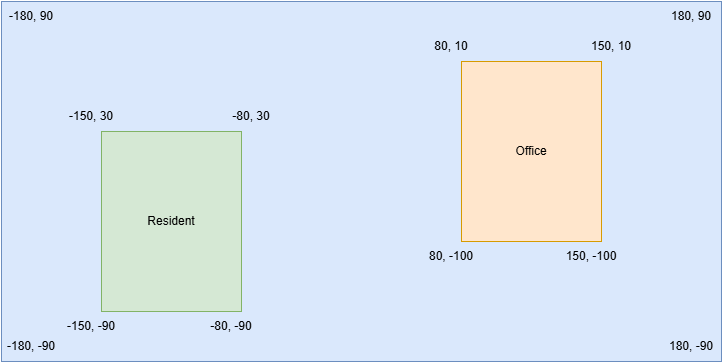

In [2]:
import sys
from pathlib import Path
sys.path.append(f"{Path().absolute().parent}")

In [3]:
import pandas as pd
from radp_library import get_ue_data, plot_ue_tracks

In [7]:
params = {
    "ue_tracks_generation": {
            "params": {
                "simulation_duration": 3600,
                "simulation_time_interval_seconds": 0.01,
                "num_ticks": 50,
                "num_batches": 1,
                "ue_class_distribution": {
                    "stationary": {
                        "count": 10,
                        "velocity": 0,
                        "velocity_variance": 1
                    },
                    "pedestrian": {
                        "count": 5,
                        "velocity": 2,
                        "velocity_variance": 1
                    },
                    "cyclist": {
                        "count": 5,
                        "velocity": 5,
                        "velocity_variance": 1
                    },
                    "car": {
                        "count": 12,
                        "velocity": 20,
                        "velocity_variance": 1
                    }
                },
                "lat_lon_boundaries": {
                    "min_lat": -90,
                    "max_lat": 90,
                    "min_lon": -180,
                    "max_lon": 180
                },
                "gauss_markov_params": {
                    "alpha": 0.5,
                    "variance": 0.8,
                    "rng_seed": 42,
                    "lon_x_dims": 100,
                    "lon_y_dims": 100,
                    "// TODO": "Account for supporting the user choosing the anchor_loc and cov_around_anchor.",
                    "// Current implementation": "the UE Tracks generator will not be using these values.",
                    "// anchor_loc": {},
                    "// cov_around_anchor": {}
            }
        }
    }
}

#### resident area ue generation
- ue(s) remain inside in resident area say for tick 0-9 [area coordinates, tick range → hyper parameters]

In [8]:
resident_params = params.copy()
resident_params["ue_tracks_generation"]["params"]["num_ticks"] = 10
resident_params["ue_tracks_generation"]["params"]['lat_lon_boundaries'] = {
    "min_lat": -120,
    "max_lat": 30,
    "min_lon": -150,
    "max_lon": -80
}

In [12]:
resident_0_9 = get_ue_data(resident_params)

print(resident_0_9.shape)
print(resident_0_9['mock_ue_id'].nunique())
print(resident_0_9['tick'].nunique())

resident_0_9.head()

(320, 4)
32
10


,mock_ue_id,lon,lat,tick
0,0,-105.567434,-58.718871,0
1,1,-111.249825,8.014259,0
2,2,-110.855280,-84.908293,0
3,3,-128.719876,-111.259758,0
4,4,-147.844780,-77.782200,0


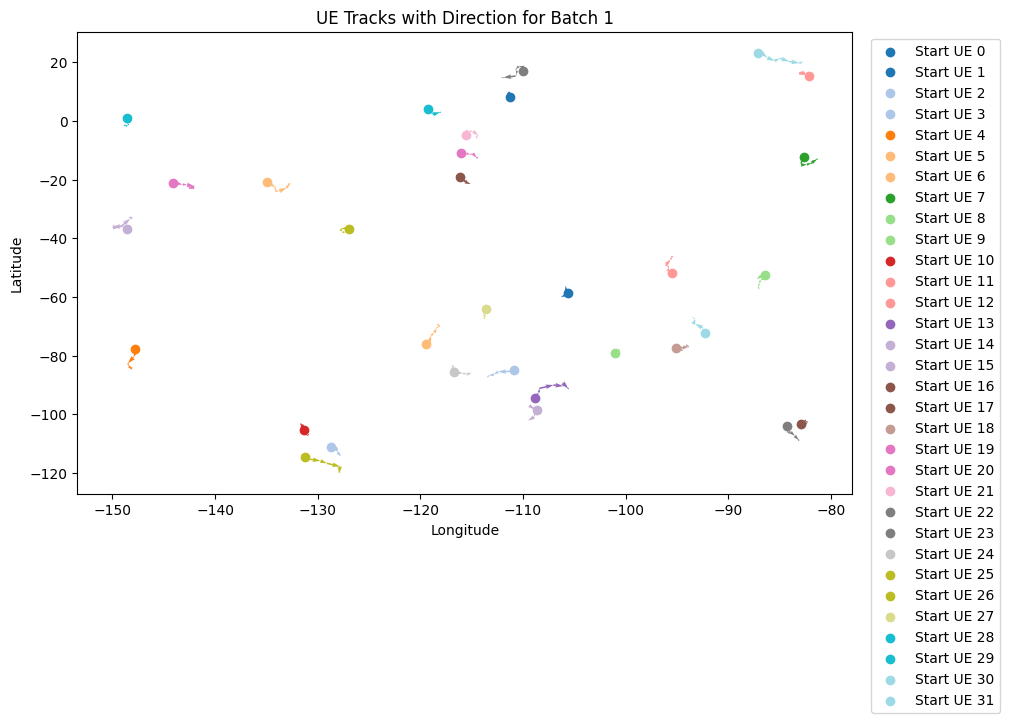

In [13]:
plot_ue_tracks(resident_0_9)

In [ ]:
resident_0_9[['lon', 'lat', 'tick']].describe()

# ? what about the ue_class_distribution? this controls number of UE for each class and their velocity.
# ? what about the gauss_markov_params?
# ? In future how to incorporate the footfall data into the UE data?
# ? Using the get_ue_data function, how to map ue_id(s) as they always start from 0, just like ticks.
# TODO: for next area (office), need to update the ticks to make it 10-19.
# TODO: check for seed control, needed for introducing the probabilistic feature, otherwise the same data will be generated each time

,lon,lat,tick
count,320.000000,320.000000,320.00000
mean,-112.322733,-50.298697,4.50000
std,19.865970,42.700226,2.87678
min,-149.991789,-119.901923,0.00000
25%,-127.734100,-85.362348,2.00000
50%,-113.442466,-57.094844,4.50000
75%,-95.376501,-12.577468,7.00000
max,-81.249382,23.277852,9.00000


In [13]:
from radp.digital_twin.mobility.ue_tracks import UETracksGenerator
from radp.digital_twin.mobility.ue_tracks_params import UETracksGenerationParams
from radp.common import constants

In [14]:
def get_ue_data2(params: dict, start_id: int = 0) -> pd.DataFrame:
    """
    Generates user equipment (UE) tracks data using specified simulation parameters.

    This function initializes a UETracksGenerationParams object using the provided parameters
    and then iterates over batches generated by the UETracksGenerator. Each batch of UE tracks
    data is consolidated into a single DataFrame which captures mobility tracks across multiple
    ticks and batches, as per the defined parameters.

    The UE tracks are returned in form of a dataframe with mock_ue_id starting from `start_id`.

    Parameters:
        - params (dict): Dictionary of simulation parameters.
        - start_id (int): The starting UE ID for the generated data. Default is 0.

    Returns:
        - pd.DataFrame: DataFrame containing UE tracks, with columns mock_ue_id, lon, lat, tick.
    """
    
    # Initialize the UE data
    ue_tracks_params = UETracksGenerationParams(params)

    ue_tracks_generation = pd.DataFrame()  # Initialize an empty DataFrame
    for ue_tracks_generation_batch in UETracksGenerator.generate_as_lon_lat_points(
        rng_seed=ue_tracks_params.rng_seed,
        lon_x_dims=ue_tracks_params.lon_x_dims,
        lon_y_dims=ue_tracks_params.lon_y_dims,
        num_ticks=ue_tracks_params.num_ticks,
        num_UEs=ue_tracks_params.num_UEs,
        num_batches=ue_tracks_params.num_batches,
        alpha=ue_tracks_params.alpha,
        variance=ue_tracks_params.variance,
        min_lat=ue_tracks_params.min_lat,
        max_lat=ue_tracks_params.max_lat,
        min_lon=ue_tracks_params.min_lon,
        max_lon=ue_tracks_params.max_lon,
        mobility_class_distribution=ue_tracks_params.mobility_class_distribution,
        mobility_class_velocities=ue_tracks_params.mobility_class_velocities,
        mobility_class_velocity_variances=ue_tracks_params.mobility_class_velocity_variances,
    ):
        # Modify the mock_ue_id to start from start_id
        ue_tracks_generation_batch[constants.MOCK_UE_ID] += start_id
        
        # Append each batch to the main DataFrame
        ue_tracks_generation = pd.concat([ue_tracks_generation, ue_tracks_generation_batch], ignore_index=True)

    return ue_tracks_generation


In [15]:
start_id = 100  # Start UE IDs from 100
data2 = get_ue_data2(params, start_id=start_id)

In [16]:
data2

,mock_ue_id,lon,lat,tick
0,100,-105.567434,-58.718871,0
1,101,-111.249825,8.014259,0
2,102,-110.855280,-84.908293,0
3,103,-128.719876,-111.259758,0
4,104,-147.844780,-77.782200,0
...,...,...,...,...
315,127,-113.787364,-65.498946,9
316,128,-118.099292,2.922508,9
317,129,-148.684646,-1.201550,9
318,130,-93.560695,-66.668841,9
